# Monocle Bone Marrow — Exploratory Notebook

This notebook:
1. Loads and preprocesses the Setty et al. 2019 bone marrow dataset
2. Plots cells coloured by cluster in UMAP and tSNE space
3. Explains and visualises root cell selection
4. Runs Monocle3 pseudotime and plots the result

In [1]:
import sys
import os
from pathlib import Path

NOTEBOOK_DIR = Path(os.getcwd())
TRAVELER_ROOT = NOTEBOOK_DIR.parents[1]
sys.path.insert(0, str(TRAVELER_ROOT / 'py_monocle'))

DATA_FILE = TRAVELER_ROOT / 'data' / 'setty_bone_marrow.h5ad'

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from py_monocle import learn_graph, order_cells

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False)

## 1. Load and preprocess

Diffusion components are computed fresh and used for root cell selection. UMAP is recomputed as the visualisation and Monocle3 trajectory target.

In [2]:
adata = sc.read(str(DATA_FILE))
print(adata)
print('\nObs columns:', adata.obs.columns.tolist())
print('Obsm keys:  ', list(adata.obsm.keys()))

AnnData object with n_obs × n_vars = 5780 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential'
    var: 'palantir'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs'
    layers: 'spliced', 'unspliced'

Obs columns: ['clusters', 'palantir_pseudotime', 'palantir_diff_potential']
Obsm keys:   ['MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs']


In [3]:
sc.pp.filter_genes(adata, min_counts=20)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)

sc.tl.pca(adata, random_state=42)
sc.pp.neighbors(adata, n_neighbors=50, n_pcs=10, random_state=42)
sc.tl.diffmap(adata, n_comps=10)
sc.tl.umap(adata, random_state=42)

print('Preprocessing done.')
print(adata)

/Users/Abhi/Desktop/TraVeLer/venv/lib/python3.9/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/Abhi/Desktop/TraVeLer/venv/lib/python3.9/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Preprocessing done.
AnnData object with n_obs × n_vars = 5780 × 11975
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential'
    var: 'palantir', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types', 'log1p', 'hvg', 'pca', 'neighbors', 'diffmap_evals', 'umap'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs', 'X_pca', 'X_diffmap', 'X_umap'
    varm: 'PCs'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'


## 2. Cells coloured by cluster

The Setty bone marrow dataset contains haematopoietic progenitor populations. Monocle3 uses the UMAP embedding to learn the principal trajectory.

In [4]:
candidate_cols = [c for c in adata.obs.columns
                  if any(k in c.lower() for k in ['cluster', 'cell', 'type', 'label', 'anno'])]
print('Candidate annotation columns:', candidate_cols)
color_col = candidate_cols[0] if candidate_cols else None
print('Using:', color_col)

Candidate annotation columns: ['clusters']
Using: clusters


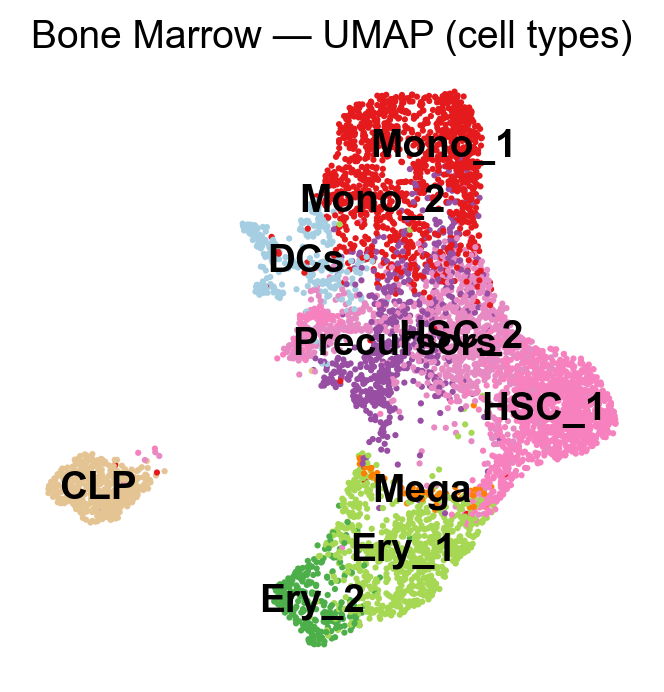

In [5]:
umap = adata.obsm['X_umap']

if color_col:
    sc.pl.umap(adata, color=color_col, legend_loc='on data',
               title='Bone Marrow — UMAP (cell types)', frameon=False, size=20)
else:
    plt.figure(figsize=(7, 5))
    plt.scatter(umap[:, 0], umap[:, 1], s=4, c='steelblue', linewidths=0)
    plt.title('Bone Marrow — UMAP')
    plt.xlabel('UMAP 1'); plt.ylabel('UMAP 2')
    plt.tight_layout(); plt.show()

## 3. Root cell selection

Root cell selection uses **tSNE space** (consistent with the DPT bone marrow experiment):

1. Take cells in the **right half** of tSNE x (i.e. `x > mean(x)`)
2. Within those, take the **upper half** (i.e. `y > mean(y)` of all cells)
3. From the resulting upper-right quadrant, select the cell with the **highest tSNE y**

**Why tSNE (not UMAP) for root selection?**  
The Setty bone marrow dataset does not come with a pre-computed UMAP, but does have a high-quality pre-computed tSNE that clearly separates haematopoietic stem cells (HSCs) into the upper-right quadrant. We use this stable pre-computed embedding for root selection, while recomputing UMAP (used for the Monocle3 graph) fresh each run.

In [ ]:
## 3. Root cell selection

Root cell = **argmin of diffusion component DC4** (`X_diffmap[:, 3]`).

**Why?**  
In the Setty bone marrow diffusion map, DC4 captures the HSC-to-progenitor axis. The cell with the minimum DC4 value sits at the most primitive end of this axis (haematopoietic stem cells), making it a stable, embedding-agnostic anchor for pseudotime.

In [6]:
umap = adata.obsm['X_umap']
dc = adata.obsm['X_diffmap']
root = int(dc[:, 3].argmin())

print(f'Root cell index : {root}')
print(f'DC4 value       : {dc[root, 3]:.4f}')
if color_col:
    print(f'Cell type label : {adata.obs[color_col].iloc[root]}')

Root cell index : 2276
DC4 value       : -0.0253
Cell type label : HSC_1


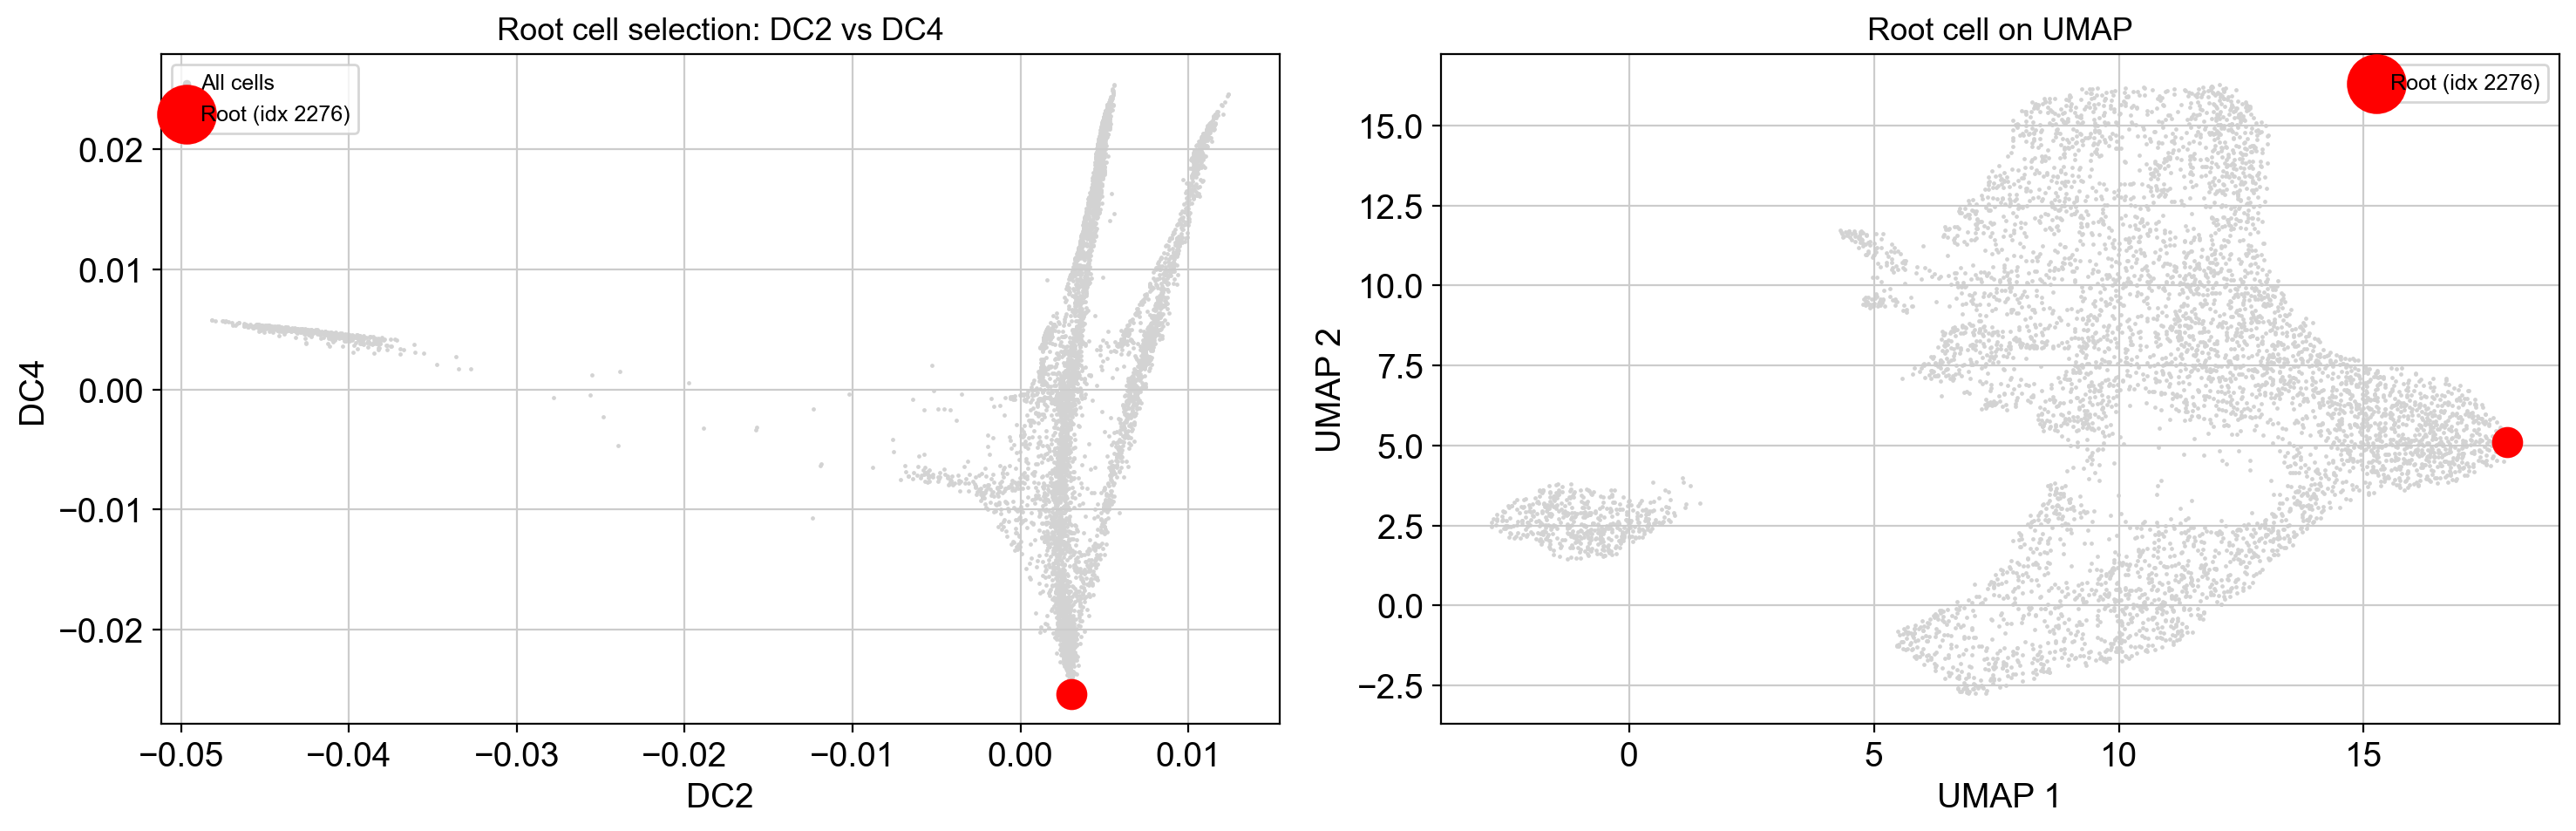

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# DC2 vs DC4 — show root selection axis
axes[0].scatter(dc[:, 1], dc[:, 3], s=3, c='lightgrey', linewidths=0, label='All cells')
axes[0].scatter(dc[root, 1], dc[root, 3], s=140, c='red', zorder=6, label=f'Root (idx {root})')
axes[0].set_title('Root cell selection: DC2 vs DC4', fontsize=13)
axes[0].set_xlabel('DC2'); axes[0].set_ylabel('DC4')
axes[0].legend(fontsize=9, markerscale=2)

# UMAP — show root
axes[1].scatter(umap[:, 0], umap[:, 1], s=3, c='lightgrey', linewidths=0)
axes[1].scatter(umap[root, 0], umap[root, 1], s=140, c='red', zorder=6, label=f'Root (idx {root})')
axes[1].set_title('Root cell on UMAP', fontsize=13)
axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')
axes[1].legend(fontsize=9, markerscale=2)

plt.tight_layout()
plt.show()

In [8]:
sc.pp.neighbors(adata, n_neighbors=50, use_rep='X_umap')
sc.tl.leiden(adata)
leiden = adata.obs['leiden'].to_numpy(dtype=int)
print(f'Number of Leiden clusters: {leiden.max() + 1}')

/var/folders/d3/d1njg5653v572jb89sxgq3yw0000gp/T/ipykernel_15058/516397446.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


Number of Leiden clusters: 25


In [9]:
projected_points, mst, centroids = learn_graph(matrix=umap, clusters=leiden)
pseudotime = order_cells(
    umap, centroids,
    mst=mst,
    projected_points=projected_points,
    root_cells=[root],
)
adata.obs['monocle_pseudotime'] = pseudotime
print('Pseudotime range:', pseudotime.min(), '–', pseudotime.max())

Pseudotime range: 0.0 – 36.23779484190056


NameError: name 'tsne' is not defined

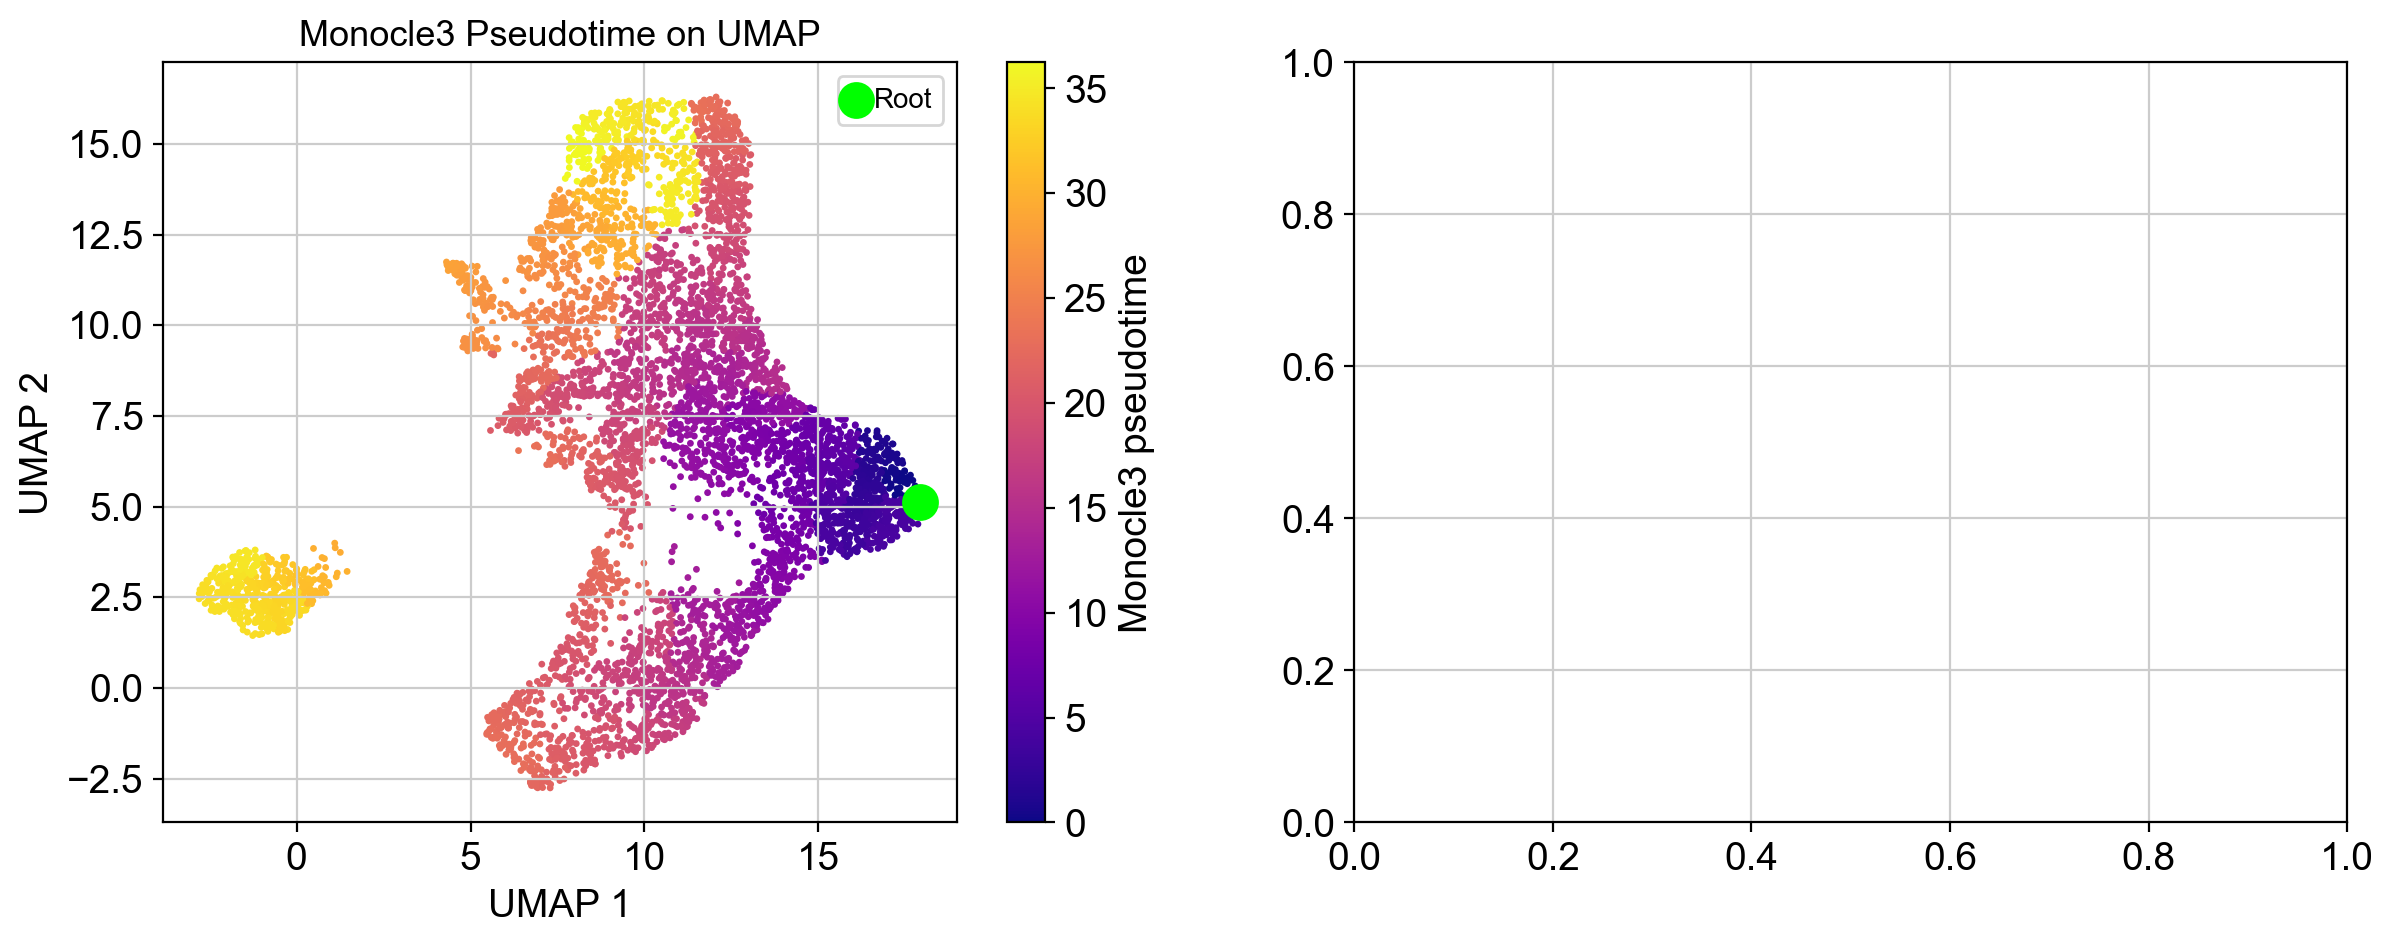

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc0 = axes[0].scatter(umap[:, 0], umap[:, 1], c=pseudotime, cmap='plasma', s=6, linewidths=0)
axes[0].scatter(umap[root, 0], umap[root, 1], s=150, c='lime', zorder=5, label='Root')
plt.colorbar(sc0, ax=axes[0], label='Monocle3 pseudotime')
axes[0].set_title('Monocle3 Pseudotime on UMAP', fontsize=13)
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
axes[0].legend(fontsize=10)

sc1 = axes[1].scatter(tsne[:, 0], tsne[:, 1], c=pseudotime, cmap='plasma', s=6, linewidths=0)
axes[1].scatter(tsne[root, 0], tsne[root, 1], s=150, c='lime', zorder=5, label='Root')
plt.colorbar(sc1, ax=axes[1], label='Monocle3 pseudotime')
axes[1].set_title('Monocle3 Pseudotime on tSNE', fontsize=13)
axes[1].set_xlabel('tSNE 1'); axes[1].set_ylabel('tSNE 2')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

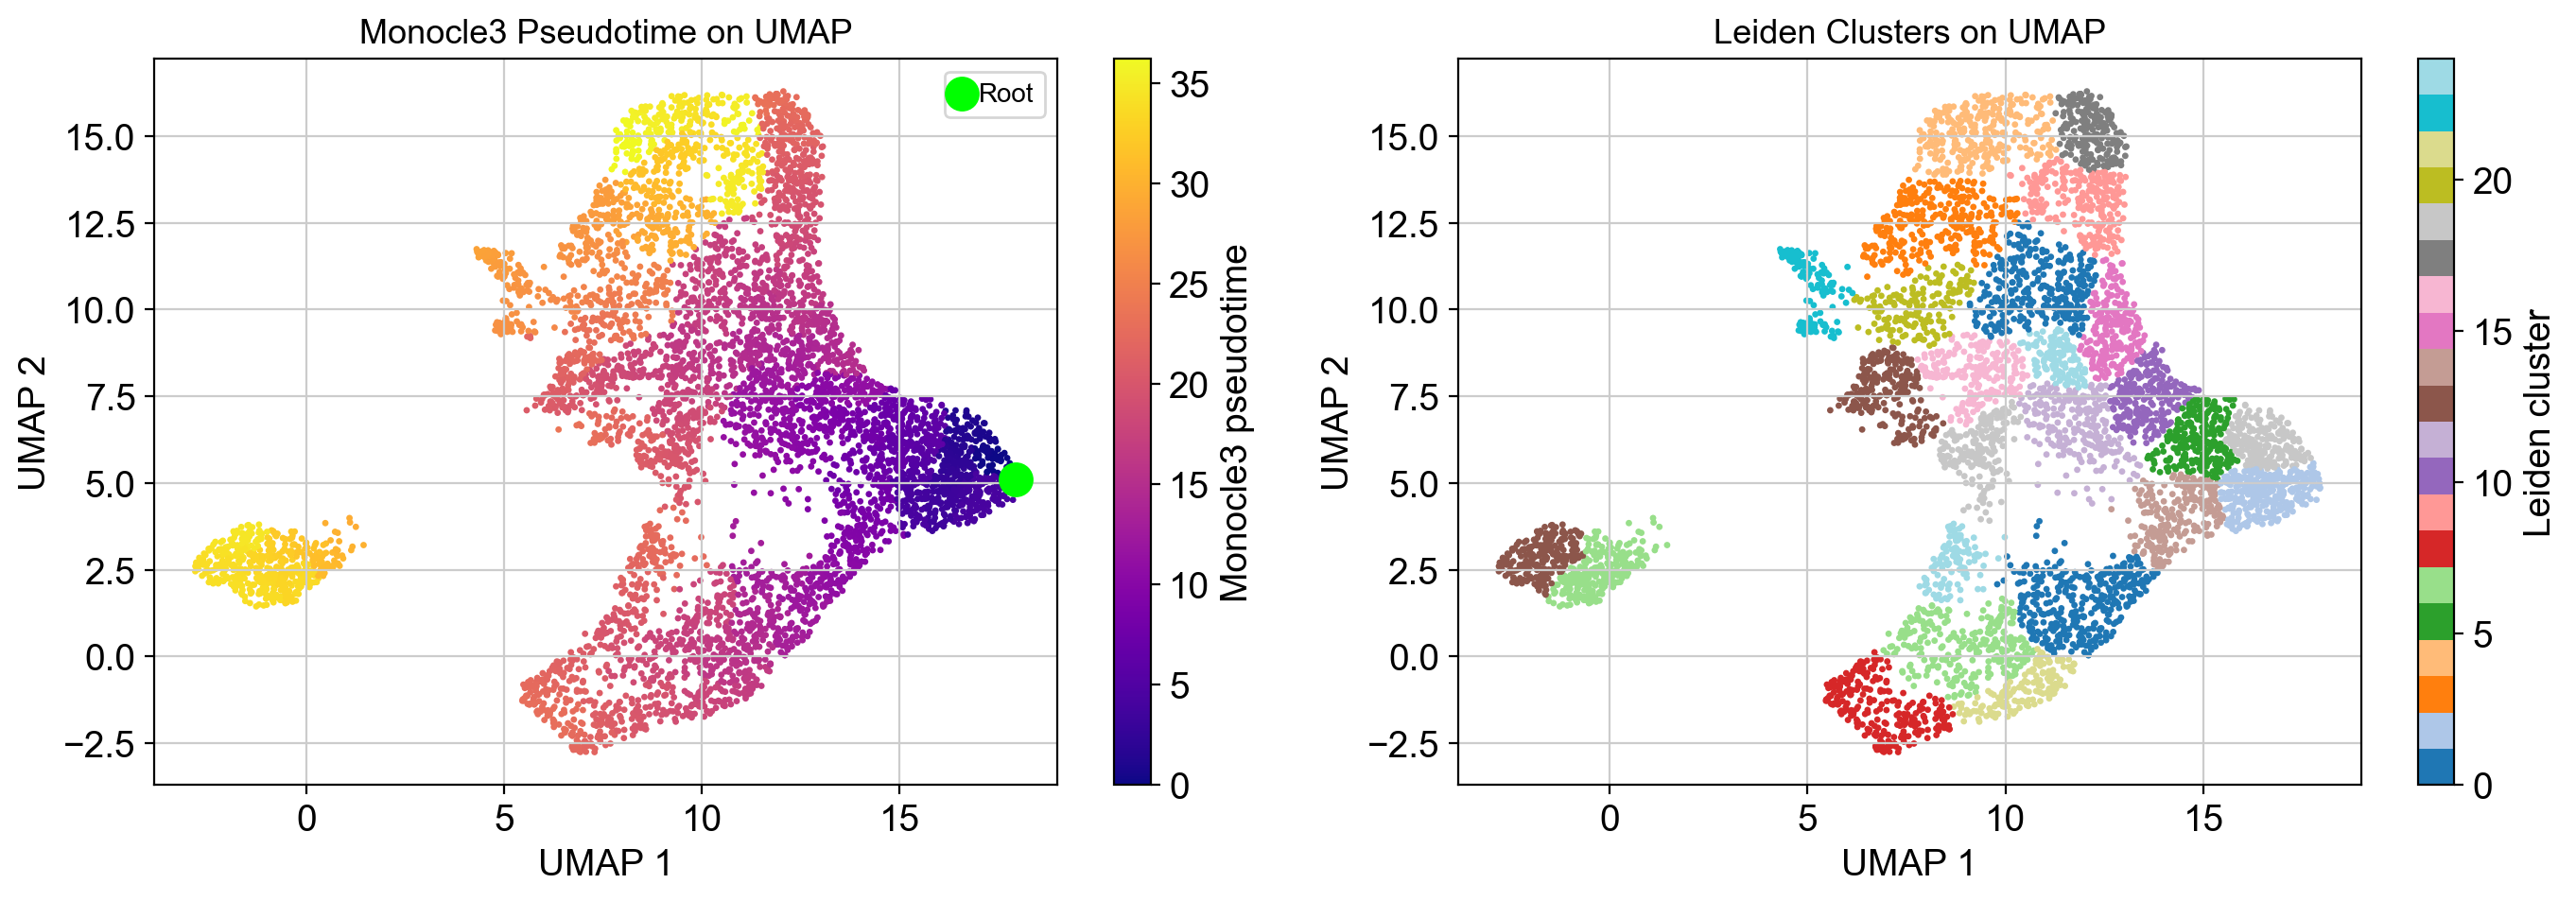

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc0 = axes[0].scatter(umap[:, 0], umap[:, 1], c=pseudotime, cmap='plasma', s=6, linewidths=0)
axes[0].scatter(umap[root, 0], umap[root, 1], s=150, c='lime', zorder=5, label='Root')
plt.colorbar(sc0, ax=axes[0], label='Monocle3 pseudotime')
axes[0].set_title('Monocle3 Pseudotime on UMAP', fontsize=13)
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
axes[0].legend(fontsize=10)

n_leiden = leiden.max() + 1
sc1 = axes[1].scatter(umap[:, 0], umap[:, 1], c=leiden, cmap='tab20',
                      vmin=0, vmax=n_leiden - 1, s=6, linewidths=0)
plt.colorbar(sc1, ax=axes[1], label='Leiden cluster')
axes[1].set_title('Leiden Clusters on UMAP', fontsize=13)
axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()